# 1. Rate of Change 速度變化率

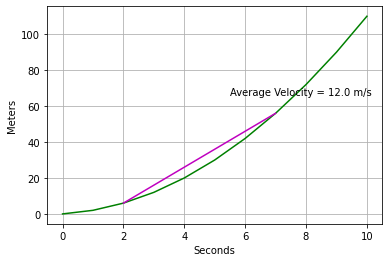

In [1]:
import numpy as np
from matplotlib import pyplot as plt
def rate(x):
    return x**2 + x

t1 = np.array(range(0, 11))
t2 = np.array([2,7])
r = (rate(11)-rate(0))/(11 - 0)   # 求平均斜率 (t1)

# 作圖
plt.xlabel('Seconds')
plt.ylabel('Meters')
plt.grid()
plt.plot(t1, rate(t1), c='g')
plt.plot(t2, rate(t2), c='m')
plt.annotate(f'Average Velocity = {str(r)} m/s',((11+0)/2, (rate(11)+rate(0))/2))
plt.show()

# 2. Limits 極限

### 2-1. Continuity function 連續函數

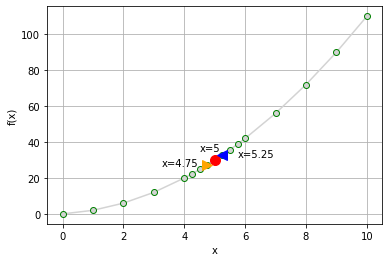

In [2]:
import matplotlib.pyplot  as plt
def f(x):
    return x**2 + x

# 加點點
add = [4.25, 4.5, 4.75, 5,  5.25, 5.5, 5.75]
x = list(range(0,5)) + add + list(range(6,11))
y = [f(i) for i in x] 

# 作圖
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.plot(x, y, c='lightgrey', marker='o', markeredgecolor='g') # , markerfacecolor='green'

# Plot f(x) when x = 5
plt.plot(5, f(5), c='r', marker='o', markersize=10)
plt.annotate('x=' + str(5),(5, f(5)), xytext=(5-0.5, f(5)+5))
# Plot f(x) when x = 5.25
plt.plot(5.25, f(5.25), c='b', marker='<', markersize=10)
plt.annotate('x=' + str(5.25),(5.25, f(5.25)), xytext=(5.25+0.5, f(5.25)-1))
# Plot f(x) when x = 4.75
plt.plot(4.75, f(4.75), c='orange', marker='>', markersize=10)
plt.annotate('x=' + str(4.75),(4.75, f(4.75)), xytext=(4.75-1.5, f(4.75)-1))

plt.show()

### 2-2. Non-Continuity function 不連續函數

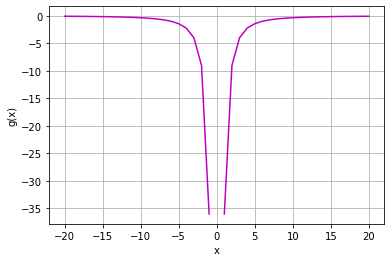

In [3]:
def g(x):
    if x != 0:
        return -(12/(2*x))**2
    
import matplotlib.pyplot as plt

x = range(-20, 21)
y = [g(a) for a in x]

# 作圖
plt.xlabel('x')
plt.ylabel('g(x)')
plt.grid()
plt.plot(x, y, c='m')

plt.show()

### 2-3. 用 sympy 計算極限值

#### A. Basic

In [4]:
import sympy as sp
import numpy as np

def lim(x_value):
    x = sp.Symbol('x')
    y = (x**3 - 2*x**2 + x) / x**2 -1
    return sp.limit(y, x, x_value)
print(lim(2))

-1/2


#### B. 無窮

In [5]:
import sympy as sp
import numpy as np

def lim(x_value):
    x = sp.Symbol('x')
    y = ((x**4)-3*(x**3)-x+3) / ((x**3)-9*x)
    return sp.limit(y, x, x_value)
print(lim(0))

-oo


#### C. 善用 if 規避無極限值

In [6]:
import sympy as sp
import numpy as np

def lim(x_value):
    if x_value != 1:
        x = sp.Symbol('x')
        y = (3*x**3 - 3) / (3**x - 3)
        return sp.limit(y, x, x_value)
    else:
        return 'fuck'
print(lim(1))

fuck


# 3. Differentiation and Derivatives

### 3-1. Two point for slope

#### A. f(4) f(6)

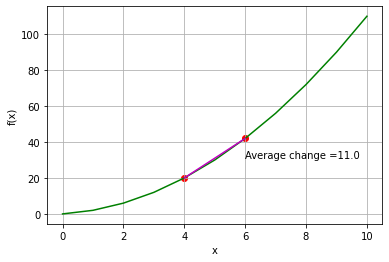

In [7]:
import matplotlib.pyplot as plt

def f(x):
    return x**2 + x

x = list(range(0, 11))
y = [f(i) for i in x]

# 指定任意兩點 f(4) & f(6)
x1, x2 = 4, 6
y1, y2 = f(x1), f(x2)
slope = (y2 - y1)/(x2 - x1)
sx = [x1, x2]
sy = [f(i) for i in sx]

# 作圖
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.plot(x, y, 'g', sx, sy, 'm')    # 畫出 f(x) & f(6)-f(4)
plt.scatter([x1, x2], [y1, y2], c='r')
plt.annotate('Average change =' + str(slope),(x2, (y2+y1)/2))

plt.show()

#### B. f(4) f(4.5000000001)

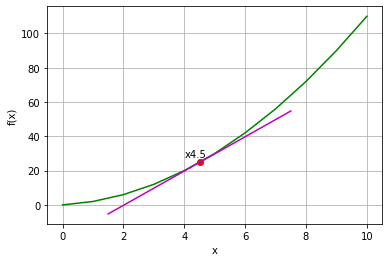

In [8]:
import matplotlib.pyplot as plt

def f(x):
    return x**2 + x

x = list(range(0, 11))
y = [f(i) for i in x]

x1, x2 = 4.5, 4.5000000001
y1, y2 = f(x1), f(x2)

# 作圖
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.plot(x, y, c='g')
plt.scatter(x1, y1, c='r')

# 為方便表示，放大切線長度
m = (y2-y1)/(x2-x1)
xMin, xMax = x1 - 3, x1 + 3
yMin, yMax = y1 - (3*m), y1 + (3*m)
plt.plot([xMin, xMax],[yMin, yMax], c='m')
plt.annotate('x' + str(x1),(x1, y1), xytext=(x1-0.5, y1+3))

plt.show()

### 3-2. Differentiability 可微性

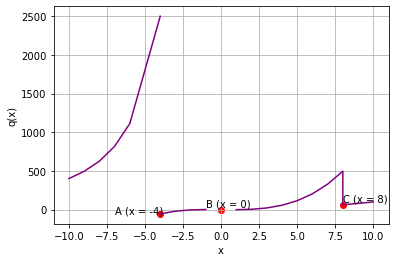

In [9]:
import matplotlib.pyplot as plt

def q(x):
    if x != 0:
        if x < -4:
            return 40000 / (x**2)
        elif x < 8:
            return (x**2 - 2) * x - 1
        else:
            return (x**2 - 2)

x1 = list(range(-10, -5)) + [-4.0001]
x2 = list(range(-4,8)) + [7.9999] + list(range(8,11))
y1 = [q(i) for i in x1]
y2 = [q(i) for i in x2]

# 作圖
plt.xlabel('x')
plt.ylabel('q(x)')
plt.grid()

# 紫線
plt.plot(x1, y1, c='purple')
plt.plot(x2, y2, c='purple')

# 紅點
xp = [-4, 0, 8]
yp = [q(-4), 0, q(8)]
plt.scatter(xp, yp, c='r')
plt.annotate('A (x = -4)',(-5, q(-3.9)), xytext=(-7, q(-3.9)))   # 切線為垂直
plt.annotate('B (x = 0)',(0, 0), xytext=(-1, 40))                # 不連續
plt.annotate('C (x = 8)',(8, q(8)), xytext=(8, 100))             # 不平滑

plt.show()

### 3-3. Derivative Rules and Operations 微分規則

#### 用 sympy 計算微分

In [10]:
import sympy as sp
import numpy as np

# 1. 微分方程式結果 f'(x)
x = sp.Symbol('x')
y = 3*x**2 + 2 
yprime = y.diff(x)
print(yprime)

# 2. 用 sub() 代入 x
x = sp.Symbol('x')
y = 3*x**3 + 2 * x
yprime = y.diff(x)
print(yprime.subs({x:7}))

# 3. 用 lambdify() 代入多個 x
f = sp.lambdify(x, yprime, 'numpy')
l = [1, 3, 5, 7, 10]
print(f(np.array(l)))      # 代入 x 計算 f'(x)

6*x
443
[ 11  83 227 443 902]


# 4. Critical Points and Optimization 臨界點與優化

### 4-1. Function Direction at a Point 某一點的函數方向

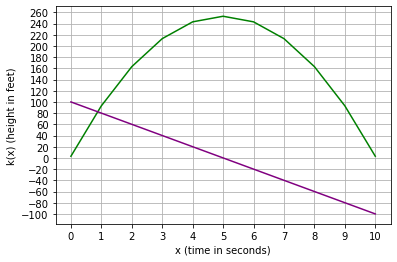

In [11]:
def k(x):
    return -10*(x**2) + (100*x)  + 3

def kd(x):
    return -20*x + 100

from matplotlib import pyplot as plt
x = list(range(0, 11))
y = [k(i) for i in x]
yd = [kd(i) for i in x]     # y 微分後的線段

# 作圖
plt.xlabel('x (time in seconds)')
plt.ylabel('k(x) (height in feet)')
plt.xticks(range(0,15, 1))
plt.yticks(range(-200, 500, 20))
plt.grid()

plt.plot(x, y, 'g', x, yd, 'purple')    # 原有曲線/微分後線
plt.show()
#當 yd=0，即為原曲線的"極值"。

### 4-2. Critical Points 臨界點

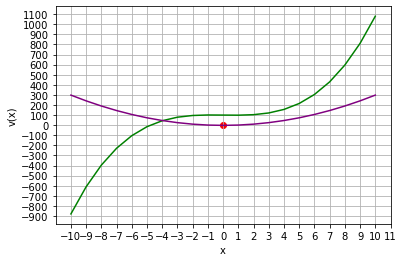

In [12]:
def v(x):
    return (x**3) - (2*x) + 100
def vd(x):
    return 3*(x**2) - 2

from matplotlib import pyplot as plt
x = list(range(-10, 11))
y = [v(i) for i in x]
yd = [vd(i) for i in x]

# 作圖
plt.xlabel('x')
plt.ylabel('v(x)')
plt.xticks(range(-10,15, 1))
plt.yticks(range(-1000, 2000, 100))
plt.grid()
plt.plot(x, y, 'g', x, yd, 'purple')
plt.scatter(0, (2/3)**0.5, c='r') # 極值點

plt.show()

### 4-3. Second Order Derivatives

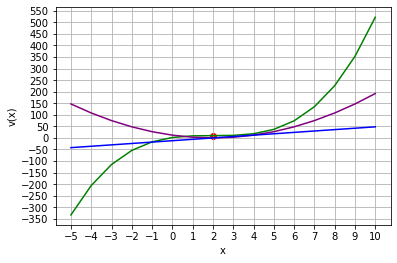

In [13]:
def v(x):
    return (x**3) - (6*(x**2)) + (12*x) + 2
def vd(x):
    return (3*(x**2)) - (12*x) + 12
def v2d(x):
    return (3*(2*x)) - 12

from matplotlib import pyplot as plt
x = list(range(-5, 11))
y = [v(i) for i in x]
yd = [vd(i) for i in x]
y2d = [v2d(i) for i in x]

# 作圖
plt.xlabel('x')
plt.ylabel('v(x)')
plt.xticks(range(-10,15, 1))
plt.yticks(range(-2000, 2000, 50))
plt.grid()

plt.plot(x, y, 'g', x, yd, 'purple', x, y2d, 'b')
plt.scatter(2, v(2), c='r')

plt.show()

# 5. Partial Derivatives 偏導數（偏微分）

### 5-1. Using the gradient 利用梯度找最小值

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 目標函數（損失函數）：f(x)
def func(x): return x ** 2 # np.square(x)
# 目標函數的一階導數：f'(x)
def dfunc(x): return 2 * x

def GD(x_start, df, epochs, lr):
    """ 梯度下降法。給定起始點與目標函數的一階導函數，求在epochs次反覆運算中x的更新值
        其原理為讓起始 x = x - dfunc(x)*lr，直到 dfunc(x) = 0，x 就不會再變，求得極值。
        :param x_start: x的起始點
        :param df: 目標函數的一階導函數
        :param epochs: 反覆運算週期
        :param lr: 學習率
        :return: x在每次反覆運算後的位置（包括起始點），長度為epochs+1
     """    
    # 此迴圈用作記錄所有起始點用
    xs = np.zeros(epochs+1)     # array[0, 0, ...0] 有1001個
    x = x_start                 # 起始點
    xs[0] = x
    for i in range(epochs):     # i = 0~999
        x += -df(x) * lr        # x = x - dfunc(x) * learning_rate
        xs[i+1] = x
    return xs

#### Case 1.

[2.00000000e+00 1.96000000e+00 1.92080000e+00 ... 3.50472169e-09
 3.43462726e-09 3.36593471e-09]


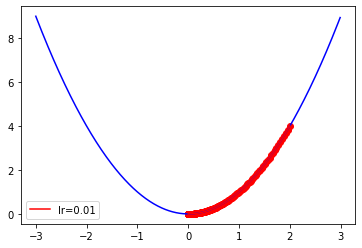

In [15]:
# 超參數（Hyperparameters）：在模型優化（訓練）前，可調整的參數。
x_start = 2                 # 起始點 (可由任意點開始)
epochs = 1000               # 執行週期數 (程式走多少迴圈停止)
learning_rate = 0.01        # 學習率 (每次前進的步伐多大)

# 梯度下降法
x = GD(x_start, dfunc, epochs, learning_rate)
print(x)

from numpy import arange
t = arange(-3, 3, 0.01)
plt.plot(t, func(t), c='b')     # 畫出所求原函數
plt.plot(x, func(x), c='r', label='lr={}'.format(learning_rate)) # 畫出紅連線
plt.scatter(x, func(x), c='r')  # 畫出紅點
plt.legend()

plt.show()

#### Case 2.

[5.         4.9        4.802      4.70596    4.6118408  4.51960398
 4.4292119  4.34062767 4.25381511 4.16873881 4.08536403 4.00365675
 3.92358362 3.84511195 3.76820971 3.69284551]


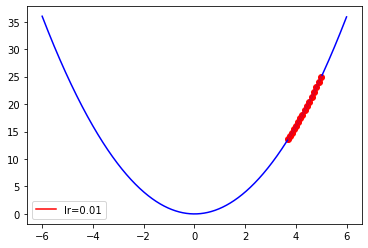

In [16]:
x_start = 5
epochs = 15
learning_rate = 0.01

x = GD(x_start, dfunc, epochs, learning_rate)
print(x)

from numpy import arange
t = arange(-6, 6, 0.01)
plt.plot(t, func(t), c='b')     # 畫出所求原函數
plt.plot(x, func(x), c='r', label='lr={}'.format(learning_rate)) # 畫出紅連線
plt.scatter(x, func(x), c='r')  # 畫出紅點
plt.legend()

plt.show()

#### Case 3.

[ 5.         -4.          3.2        -2.56        2.048      -1.6384
  1.31072    -1.048576    0.8388608  -0.67108864  0.53687091 -0.42949673
  0.34359738 -0.27487791  0.21990233 -0.17592186]


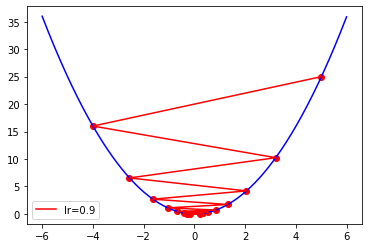

In [17]:
x_start = 5
epochs = 15
learning_rate = 0.9

x = GD(x_start, dfunc, epochs, learning_rate)
print(x)

from numpy import arange
t = arange(-6, 6, 0.01)
plt.plot(t, func(t), c='b')     # 畫出所求原函數
plt.plot(x, func(x), c='r', label='lr={}'.format(learning_rate)) # 畫出紅連線
plt.scatter(x, func(x), c='r')  # 畫出紅點
plt.legend()

plt.show()

# 6. Integration 積分

### 6-1. Basic

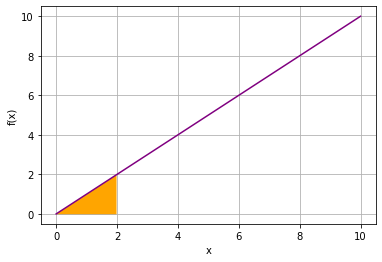

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define function f
def f(x):
    return x
x = range(0, 11)
y = [f(a) for a in x]

# 作圖
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.plot(x, y, color='purple')
p = np.arange(0, 2, 1/20)
plt.fill_between(p, f(p), color='orange')

plt.show()

### 6-2. 利用 scipy 計算定積分

In [19]:
import scipy.integrate as integrate
# Define function f
def f(x):
    return x + 1

# 計算 x=a→b 定積分 intergrate.quad(func, a, b)
i, e = integrate.quad(lambda x: f(x), 0, 2)
i, e    # i 為定積分結果，e 為計算誤差值

(4.0, 4.440892098500626e-14)

### 6-3. Infinite limits 無窮極限

In [20]:
import scipy.integrate as inte
import numpy as np

i, e = inte.quad(lambda x: np.e**(-5*x), 0, np.inf)
print(i)

0.20000000000000007


### 6-4. Normal distribution 常態分配

#### A. 常態分配機率積分

In [21]:
nor = lambda x: np.exp(-x**2 / 2.0)/np.sqrt(2.0 * np.pi)
i, e = inte.quad(nor, -np.inf, np.inf)
print('Total Probability:', i)

Total Probability: 0.9999999999999998


#### B. 一倍標準差

In [22]:
i, e = inte.quad(nor, -1, 1)
print('1-sigma:', i)

1-sigma: 0.682689492137086


#### C. 1.96 倍標準差（信賴水準 95%）

In [23]:
i, e = inte.quad(nor, -1.96, 1.96)
print('1.96-sigma:', i)

1.96-sigma: 0.9500042097035591


#### D. 三倍標準差（可達 99.7%）

3-sigma: 0.9973002039367399


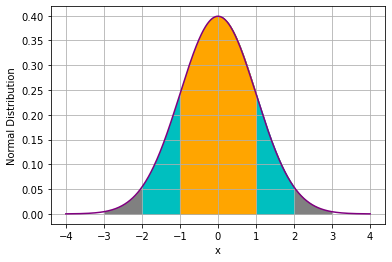

In [24]:
i, e = inte.quad(nor, -3, 3)
print('3-sigma:', i)

# 作圖
x = np.linspace(-4, 4, 1000)
y = nor(x)
plt.xlabel('x')
plt.ylabel('Normal Distribution')
plt.grid()

plt.plot(x, y, color='purple')
sig1 = np.linspace(-1, 1, 500)   # 68.3%
sig2 = np.linspace(-2, 2, 500)   # 95.4% (假設檢定常用 2 或 1.96-sigma)
sig3 = np.linspace(-3, 3, 500)   # 99.7%
plt.fill_between(sig3, nor(sig3), color='0.5')
plt.fill_between(sig2, nor(sig2), color='c')
plt.fill_between(sig1, nor(sig1), color='orange')

plt.show()

# Exercise

$(x+2)(x-3) = (x-5)(x-6)$

In [25]:
import sympy as sp
x = sp.Symbol('x')
sp.solvers.solve((x+2)*(x-3)-(x-5)*(x-6), x)

[18/5]

In [26]:
import sympy as sp
exp1='(x+2)*(x-3), (x-5)*(x-6)'
sp.solvers.solve(sp.core.sympify(f"Eq({exp1})"))

[18/5]

$\lvert 10-2x \rvert = 6$

In [27]:
# 若要計算絕對值，須加上 real=True
x = sp.Symbol('x', real=True) # real=True 表 x 是實數
sp.solvers.solve(abs(10-2*x)-6, x)

[2, 8]

$4x + 3y = 4$<br>
$2x + 2y - 2z = 0$<br>
$5x + 3y + z = -2$<br>

In [28]:
# 1. numpy 解法
import numpy as np
left = str(input("請輸入等號左測導數 (以','逗號隔開): "))
left = left.split(',')
left = list(map(int, left))

right = str(input("請輸入等號右測導數 (以','逗號隔開): "))
right = right.split(',')
right = list(map(int, right))

a_shape = int(len(left)**0.5)  # 得到矩陣形狀
a = np.array(left).reshape(a_shape, a_shape) # 重整矩陣為正方形
b = np.array(right)
np.linalg.solve(a, b)

請輸入等號左測導數 (以','逗號隔開): 4,3,0,2,2,-2,5,3,1
請輸入等號右測導數 (以','逗號隔開): 4,0,-2


array([-11.,  16.,   5.])

In [29]:
# 2. sympy 解法
from sympy.solvers import solve
eq = []

while True:
    inp = input('請輸入方程式: ')# 乘號以*輸入
    if inp =='':
        break
    eq.append(inp)
if len(eq)>0:
    for i in range(len(eq)):
        arr = eq[i].split('=')
        if len(arr) ==2:
            eq[i] = arr[0] + '-(' + arr[1] + ')'
    print(solve(eq))

請輸入方程式: 4*x+3*y=4
請輸入方程式: 2*x+2*y-2*z=0
請輸入方程式: 5*x+3*y+z=-2
請輸入方程式: 
{x: -11, y: 16, z: 5}


In [30]:
from sympy.solvers import solve

def run():
    eq_clean = []
    exp = text.get('1.0', 'end')    # 把輸入區塊的東西丟進 exp
    eq = exp.split('\n')            # 用 '\n' 拆分
    if len(eq) > 0:                 # 若輸入的東西不是空白的
        for i in range(len(eq)):    # i = 輸入幾個多項式
            if eq[i] == '':
                continue
            arr = eq[i].split('=')  # arr = 每個多項式用 '=' 拆分
            if len(arr) == 2:       # 若只有兩項 (也就是只有等號左右側)
                eq[i] = arr[0] + '-(' + arr[1] + ')'
            eq_clean.append(eq[i])  # 把 eq[0] 加入 eq_clean
        ans.set(solve(eq_clean))    # 把 eq_clean 丟進 sympy 求解，放入變數 ans

In [31]:
import tkinter as tk

# 1. 宣告一個根視窗
root = tk.Tk()

# 2. 建立顯示字元區塊
# text= : 顯示字元
# height=1 : 高度為1
# font= : 字體 大小 粗體
tk.Label(root, text='請輸入方程式: (2x 須輸入 2*x)', height=1, font='Helvetic 18 bold').pack(fill=tk.X)

# 3. 建立可輸入區塊
text = tk.Text(root, height=5, width=30, font='Helvetic 18 bold')
text.pack()

# 4. 建立按紐觸發 run() 函數
# commend= : 事件處理，通常會接一個函數
tk.Button(root, text='求解', font='Helvetic 36 bold', command=run).pack(fill=tk.X)

# 5. 建立顯示答案區塊
# textvariable= : 需求顯示的字元
ans = tk.StringVar()
tk.Label(root, text='', height=1, font='Helvetic 18 bold', textvariable=ans).pack(fill=tk.X)

# 6. 監聽事件
root.mainloop()

### Gradient descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.core.symbol import Symbol

# 梯度下降法
def GD(x_start, df, epochs, lr):    
    xs = np.zeros(epochs+1)    
    x = x_start
    xs[0] = x
    for i in range(epochs):
        dx = df(x)
        x += -dx * lr
        xs[i+1] = x
    return xs

### 1. $f(x) = x^3 - 2x + 100$

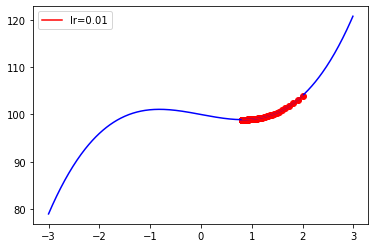

In [2]:
# 目標函數（損失函數）：f(x)
def func(x): return x**3-2*x+100
# 目標函數的一階導數：f'(x)
def dfunc(x): return 3*x**2-2

# 超參數（Hyperparameters）
x_start = 2
epochs = 1000
learning_rate = 0.01

x = GD(x_start, dfunc, epochs, learning_rate)

from numpy import arange
t = arange(-3, 3, 0.01)
plt.plot(t, func(t), c='b')     # 畫出所求原函數
plt.plot(x, func(x), c='r', label='lr={}'.format(learning_rate)) # 畫出紅連線
plt.scatter(x, func(x), c='r')  # 畫出紅點
plt.legend()

plt.show()

### 2. $f(x) = -5x^2 + 3x + 6$

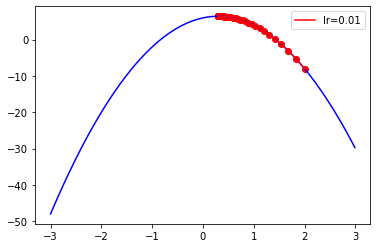

In [3]:
# 目標函數（損失函數）：f(x)
def func(x): return -5*x**2+3*x+6
# 目標函數的一階導數：-f'(x)
def dfunc(x): return 10*x-3

# 超參數（Hyperparameters）
x_start = 2
epochs = 1000
learning_rate = 0.01

x = GD(x_start, dfunc, epochs, learning_rate)

from numpy import arange
t = arange(-3, 3, 0.01)
plt.plot(t, func(t), c='b')     # 畫出所求原函數
plt.plot(x, func(x), c='r', label='lr={}'.format(learning_rate)) # 畫出紅連線
plt.scatter(x, func(x), c='r')  # 畫出紅點
plt.legend()

plt.show()

### 3. $f(x) = 2x^4 - 3x^2 + 2x - 20$

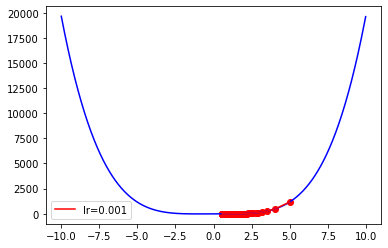

In [4]:
# 目標函數（損失函數）：f(x)
def func(x): return 2*x**4-3*x**2+2*x-20
# 目標函數的一階導數：f'(x)
def dfunc(x): return 8*x**3-6*x+2

# 超參數（Hyperparameters）
x_start = 5
epochs = 1000
learning_rate = 0.001

x = GD(x_start, dfunc, epochs, learning_rate)

from numpy import arange
t = arange(-10, 10, 0.01)
plt.plot(t, func(t), c='b')     # 畫出所求原函數
plt.plot(x, func(x), c='r', label='lr={}'.format(learning_rate)) # 畫出紅連線
plt.scatter(x, func(x), c='r')  # 畫出紅點
plt.legend()

plt.show()

### 4. $f(x) = \sin(x) e^{-0.1(x-0.6)^2}$

In [2]:
from sympy import *
x = Symbol('x')
y = sin(x)* E ** (-0.1*(x-0.6)**2)
dy = y.diff(x) # 把方程式微分求一階導函數

def func(x):
    return np.sin(x)*np.exp(-0.1*(x-0.6)**2)
def dfunc(x_self):
    return dy.subs(x, x_self).evalf() # 把 x_self 用 sub 函數迭代入 dy

#### 4.1

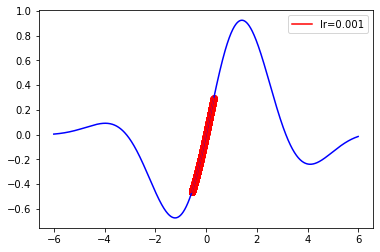

In [6]:
# 超參數（Hyperparameters）
x_start = 0.3
epochs = 1000
learning_rate = 0.001

x = GD(x_start, dfunc, epochs, learning_rate)

from numpy import arange
t = arange(-6, 6, 0.01)
plt.plot(t, func(t), c='b')     # 畫出所求原函數
plt.plot(x, func(x), c='r', label='lr={}'.format(learning_rate)) # 畫出紅連線
plt.scatter(x, func(x), c='r')  # 畫出紅點
plt.legend()

plt.show()

#### 4.2

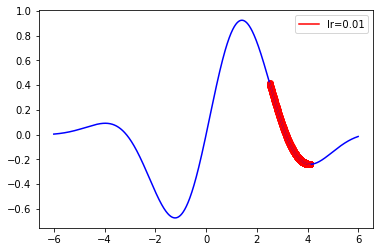

In [3]:
# 超參數（Hyperparameters）
x_start = 2.5
epochs = 1000
learning_rate = 0.01

x = GD(x_start, dfunc, epochs, learning_rate)

from numpy import arange
t = arange(-6, 6, 0.01)
plt.plot(t, func(t), c='b')     # 畫出所求原函數
plt.plot(x, func(x), c='r', label='lr={}'.format(learning_rate)) # 畫出紅連線
plt.scatter(x, func(x), c='r')  # 畫出紅點
plt.legend()

plt.show()